## Video Frame Tracking - (SIFT) Pipeline


In [2]:
# Setup 

# Essential Libraries
import cv2
import matplotlib.pyplot as plt

# Define | Data Directory
image_dir = "C:/Users/Zed/Desktop/AIML331/Assignment 2/AIML331_A2_Data/data/"

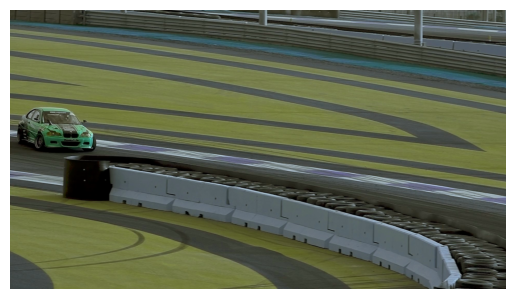

In [3]:
# Image Preparation -> Analysis

# Inital View | Original Image State
img = cv2.imread(image_dir + 'frame_0.jpg', 1)      # 1 for (BGR Format) (Blue, Green, Red)  
#img = cv2.imread('frame_0', 1)                     # If images are within the same directory | USE THIS INSTEAD
height, width, channels = img.shape                 # Image Dimensions
plt.imshow(img)
plt.axis('off')
plt.show()

# References 1

##### References 1
- How to iterate through images in a folder Python?
    - GeeksforGeeks. (2021, November 26). How to iterate through images in a folder Python? GeeksforGeeks. https://www.geeksforgeeks.org/python/how-to-iterate-through-images-in-a-folder-python/

‌

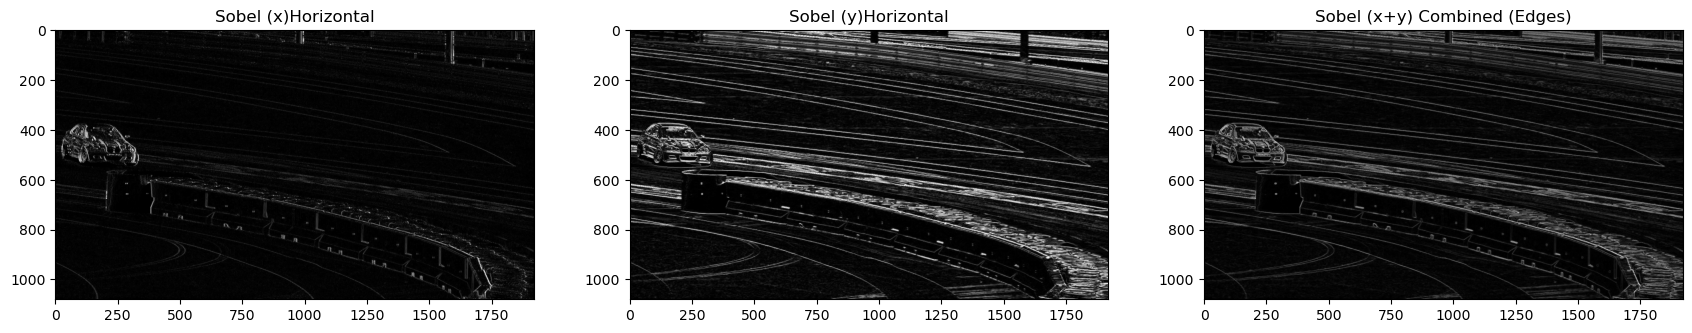

In [4]:
##### Image Gadient and Edge Detecion 

# Image Preparation | Image Stage 2 | Grayscale Conversion | 

gray_var = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)    # Edge Detection Algs. | Intensity Gradients | Needs grayscale imgs.

# Apply Sobel Operator ( (x)Horizontal  + (y)Vertical Directions )
sobel_x = cv2.Sobel(gray_var, cv2.CV_64F, 1, 0, ksize=3)    # X gradient
sobel_y = cv2.Sobel(gray_var, cv2.CV_64F, 0, 1, ksize=3)    # Y gradient

# Convert to Absolute Values
sobel_x = cv2.convertScaleAbs(sobel_x)
sobel_y = cv2.convertScaleAbs(sobel_y)

# Combine gradients
sobel_comb = cv2.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

# Display Results
plt.figure(figsize=(21,21))
plt.subplot(1,3,1), plt.imshow(sobel_x, cmap='gray'), plt.title("Sobel (x)Horizontal")
plt.subplot(1,3,2), plt.imshow(sobel_y, cmap='gray'), plt.title("Sobel (y)Horizontal")
plt.subplot(1,3,3), plt.imshow(sobel_comb, cmap='gray'), plt.title("Sobel (x+y) Combined (Edges)")
plt.show()


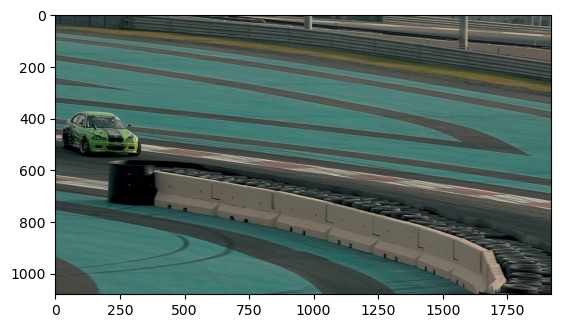

In [5]:
### Harris Corner Detection -> Infer image features
#  Analyse -> img gradients over a local reagion -> "Find significant intensity change within a window"
#  Maximize -> Intensity change function E(u,v) as the sum of all the sum squared differences (SSD)
#  Utilize -> Corner Response Funcion -> Estimate "Maximize" process

# 1.1 Prepare Image | img. Color Conversion (BGR -> RGB)
img_copy = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_copy)


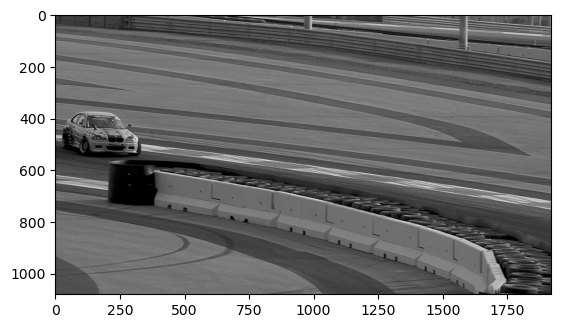

In [7]:
# 1.2 Prepare Image | For second moment matrix | img. Color Conversion (RGB -> Grayscale)
img_copy_gray_var = cv2.cvtColor(img_copy, cv2.COLOR_RGB2GRAY)
plt.imshow(img_copy_gray_var, cmap='gray')

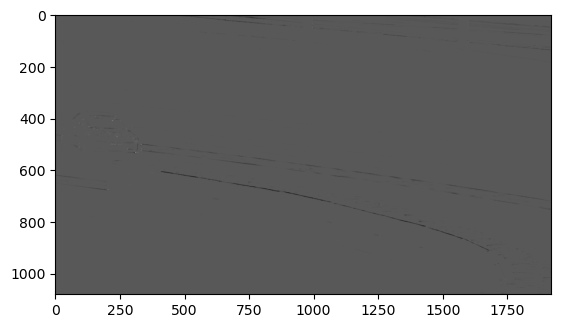

In [12]:
# 2. Detect Corners
#                     (input img, window size, sobel kernel size, K parameter of R response function)
dst = cv2.cornerHarris(img_copy_gray_var, 3, 3, 0.04)

# Enchance Corner Points -> Dilate corner image
#dst = cv2.dilate(dst, None) 

plt.imshow(dst, cmap='gray')

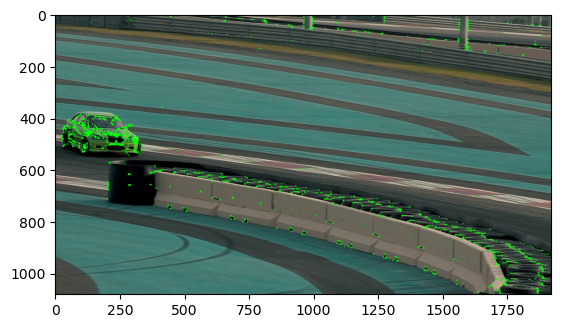

In [31]:
#3. Extract & Display -> Strong corners
# Detectionn | Threshold value | Sensitivity Knob -> how many corners you want to detect
thresh = 0.001*dst.max()

# Draw Corners -> Image Copy
corner_img = img_copy.copy()

# Iterate & Draw -> All threshold passing corners  
for j in range(0, dst.shape[0]):
    for i in range(0, dst.shape[1]):
        if(dst[j,i] > thresh):
            # image, center pt, radius, color, thickness
            cv2.circle( corner_img, (i, j), 1, (0,255,0), 1)

plt.imshow(corner_img)

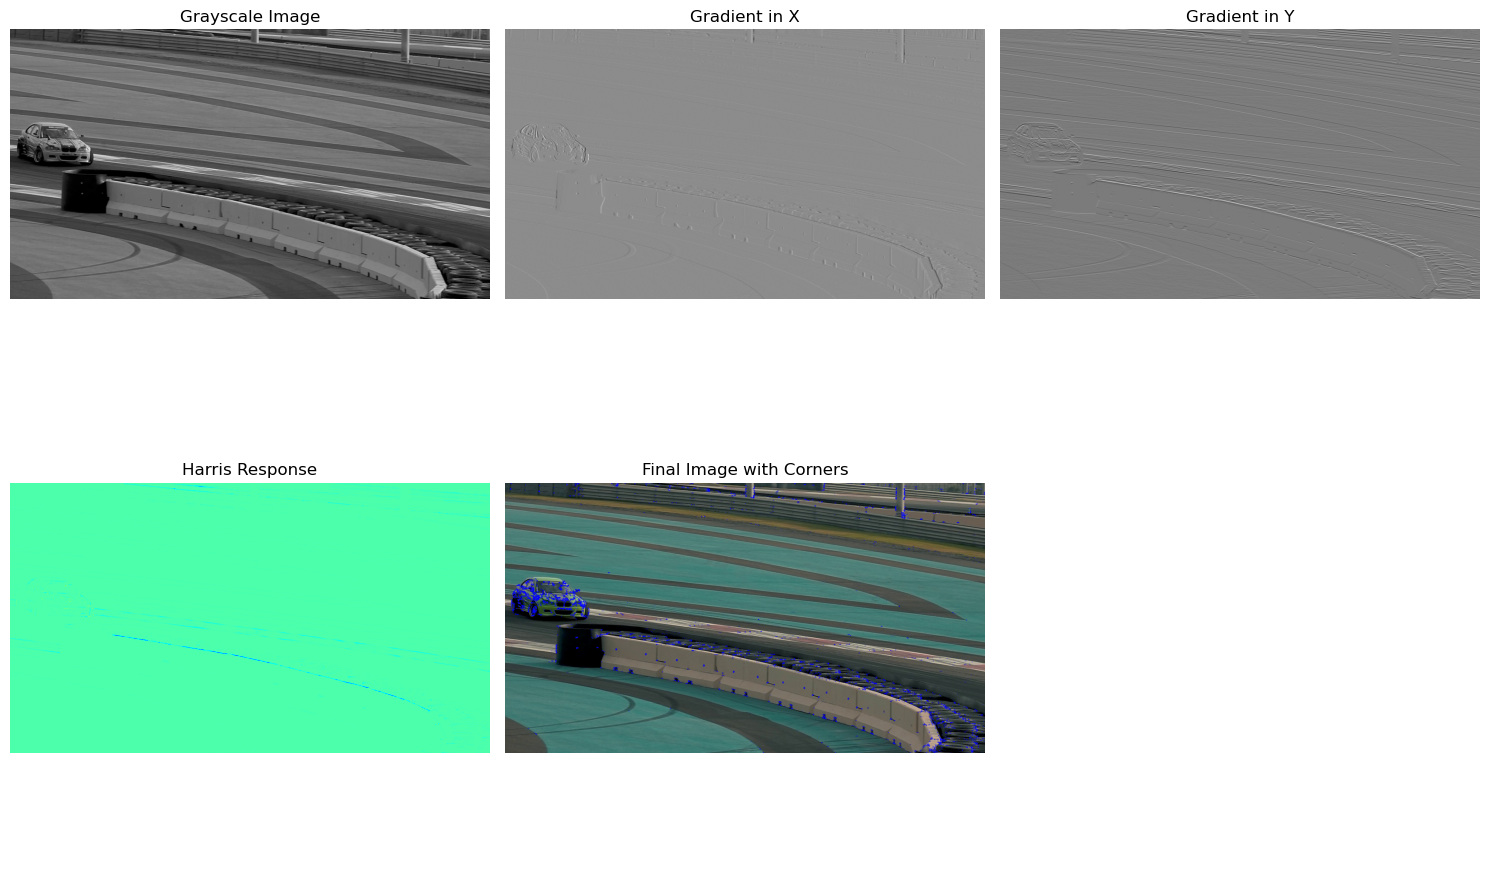

In [36]:
# 3. Step by Step - Harris Corner Detection

# Step 1: Compute Image Gradients -> Use sobel
Ix = cv2.Sobel(img_copy_gray_var, cv2.CV_64F, 1, 0, ksize=3)  # Gradient (x)
Iy = cv2.Sobel(img_copy_gray_var, cv2.CV_64F, 0, 1, ksize=3)  # Gradient (y)

# Step 2: Compute -> Products of derivatives
Ix2 = Ix ** 2
Iy2 = Iy ** 2
Ixy = Ix * Iy

# Step 3: Apply -> Gaussian smoothing -> derivative products | Summation implicitly occurs on a sliding window
Ix2 = cv2.GaussianBlur(Ix2, (3, 3), 1)
Iy2 = cv2.GaussianBlur(Iy2, (3, 3), 1)
Ixy = cv2.GaussianBlur(Ixy, (3, 3), 1)

# Step 4: Compute -> Harris response R = det(M) - k * (trace(M)^2)
k = 0.04  # Harris constant
det_M = (Ix2 * Iy2) - (Ixy ** 2)  # Determinant of M
trace_M = Ix2 + Iy2               # Trace of M
R = det_M - k * (trace_M ** 2)    # Harris Response

# Normalize -> The response for visualization
R_norm = cv2.normalize(R, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)

# Step 5: Threshold -> the response to find corners
threshold = 0.0001 * R.max()
corner_img = img_copy.copy()
corner_img[R > threshold] = [0, 0, 255]  # Mark corners | red


# Display results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(img_copy_gray_var, cmap='gray')
axes[0, 0].set_title("Grayscale Image")

axes[0, 1].imshow(Ix, cmap='gray')
axes[0, 1].set_title("Gradient in X")

axes[0, 2].imshow(Iy, cmap='gray')
axes[0, 2].set_title("Gradient in Y")

axes[1, 0].imshow(R_norm, cmap='jet')
axes[1, 0].set_title("Harris Response")

axes[1, 1].imshow(corner_img)
axes[1, 1].set_title("Final Image with Corners")

# axes[1, 2].imshow(corner_img_refine)
# axes[1, 2].set_title("Final Image with Corners")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()


##### References 2
- **** Image Gradient and Edge Detection*****
    - tutorial_week4.ipynb
- **** Harris Corner Detection****
    - tutorial_week4.jpynb
‌

##### SIFT Scale Invariant Feature Transform
-  KEY STEPS:
    1. Position-scale peak selection -> Potential area | Locate features
    2. Keypoint Localization -> Accurately locate feature keypoints 
    3. Orientation Normalization -> Rotate orientation of the patch to our keypoints.
    4. Keypoint descriptor -> Describe the keypoints as a high dimensional vector [orientation histogram]
    5. Keypoint Matching

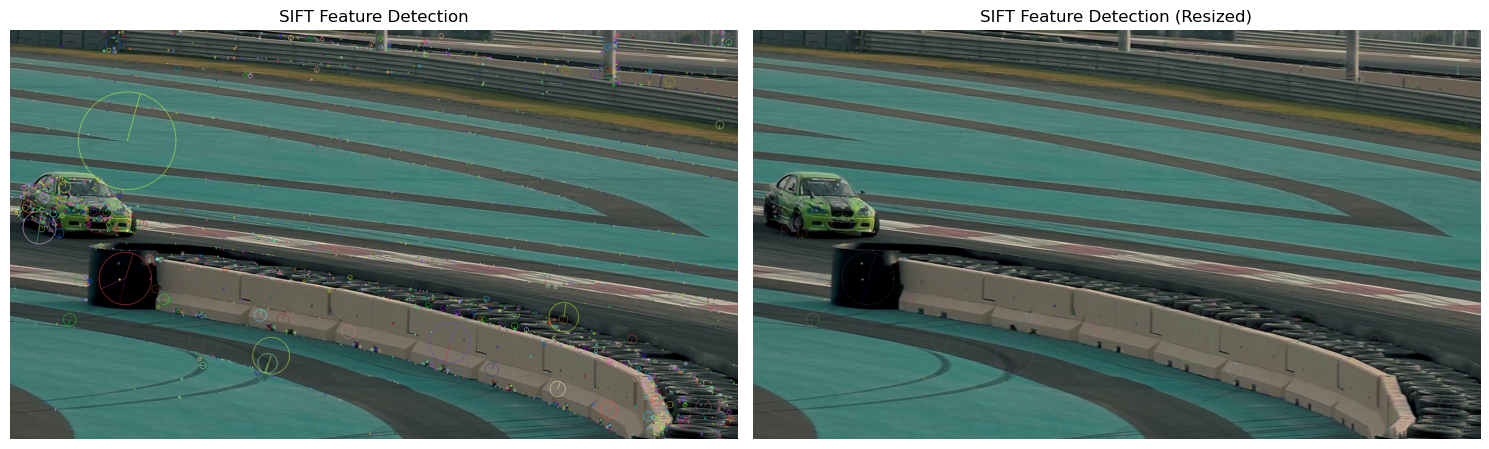

In [38]:
##### SIFT Feature Detection +++++

### Duplicate a copy | SIFT purposes only
sift_gray = img_copy_gray_var.copy()

sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(sift_gray, None)
img_sift = cv2.drawKeypoints(img, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Compare -> with SIFT keypoints | under large scale image
# # # Scaling factor
height,width = img.shape[:2]
scale_x = 4  # Double the width
scale_y = 4  # Increase the height by 1.5

##### New Dimensions Section
#
# Calculate -> new dimensions
new_width = int(width * scale_x)
new_height = int(height * scale_y)

image_resize = cv2.resize(img, (new_width, new_height)) 

# Change color to RGB (from BGR)
image_copy_resize = cv2.cvtColor(image_resize, cv2.COLOR_BGR2RGB)

# Convert to grayscale, remember the second moment marix are calculated in the intensity of the image
gray_resize = cv2.cvtColor(image_copy_resize, cv2.COLOR_RGB2GRAY)
#
###### 

##### SIFT Feature Detection | Continued +++++
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_resize, None)
img_sift_resize = cv2.drawKeypoints(image_resize, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Create a figure with a larger size (e.g., 15x7 inches)
plt.figure(figsize=(15, 7))
# Create a 1x2 subplot
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
plt.title('SIFT Feature Detection')
plt.axis('off')

# Plot the second image in the second subplot
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img_sift_resize, cv2.COLOR_BGR2RGB))
plt.title('SIFT Feature Detection (Resized)')
plt.axis('off')

# Display the plot
plt.tight_layout()
plt.show()


##### References 3
- **** SIFT Keypoint (Scale Invariant Feature Transform)**** 
    - tutorial_week4.ipynb


## Video Frame Tracking - (SIFT) Pipeline


##### 1. Find (Keypoints) Local Features - (DoG)
- Build: Gaussian Pyramid
- Calculate: (Dog) Difference of Gaussians
- Find: ____ existing across multiple frames

##### 2. Localisation
- Find: Local extrema
- Prune: "bad" points (Stable - (x, y, σ) coordinates)

##### 3. Orientation
- Create: Histogram (Local gradients)
- Find: Dominant peak
- Assign: "Up" direction -> keypoint | Give rotation invariance

## Keypoint Matching (Finding Correspondences)

##### 4. Describe their patterns (SIFT Descriptors)
- Build: 4x4 Grid of orientation Histograms
    - 16 cells x 8 bins
- Create: 128-dimensional vector -> uniquely identifies each patch
- GOAL: Descriptor - Invariant to translation, scale, rotation, and lighting!

##### 3. Correspondence Matching (Pairwise Matching)

##### 4. Outlier Removal (RANSAC)

## Keypoint Visualization

##### 1. Indicate Positions - Successfully Tracked Points -> Video Frames
- Overlay connecting line (previous position -> current position) across successive frames

## References

- Puzzle Piece Awarness: SIFT Outline | w4_lec02_Local Feature_DoG and SIFT.pdf
- w5_Tutorial.pdf


- Online APA 7 | Website Citator
    - https://www.mybib.com/tools/apa-citation-generator